# Insurance costs — first notebook

This notebook walks through the **medical insurance** dataset: loading it, poking around, cleaning encodings, adding a BMI band feature, then some quick stats (correlation and chi-square) before picking columns for whatever we build next.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("insurance-checkpoint.csv")

In [9]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## First look at the data

Shape, types, missing values, quick plots — the usual sanity check before we touch anything.

In [10]:
df.shape

(1338, 7)

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [15]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [16]:
numeric_columns= ['age', 'bmi', 'children', 'charges']

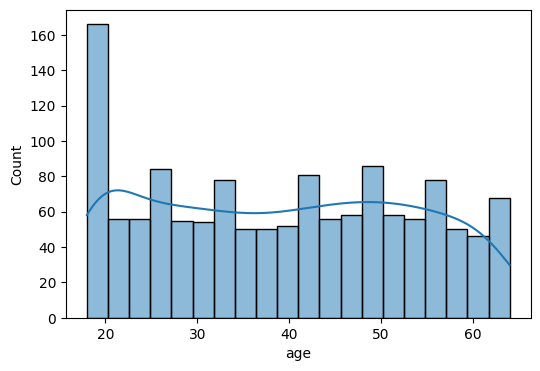

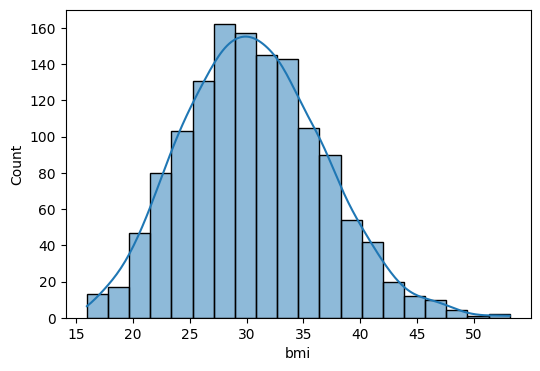

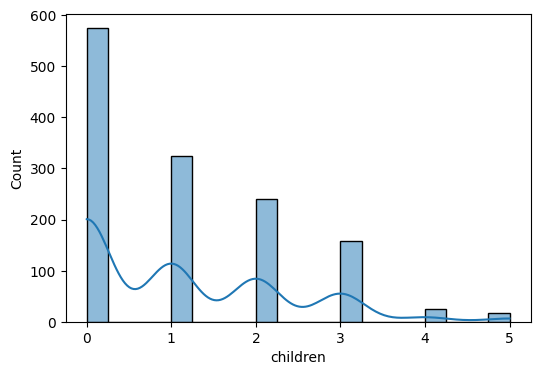

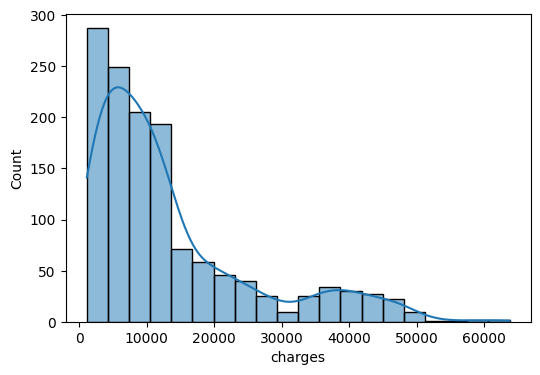

In [17]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True, bins = 20)

<Axes: xlabel='count', ylabel='sex'>

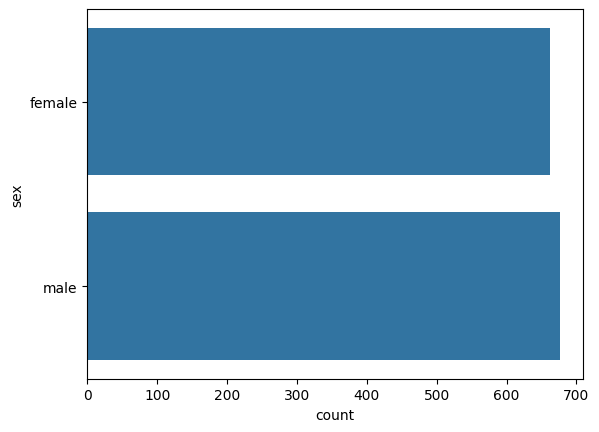

In [18]:
sns.countplot(df['sex'])

<Axes: ylabel='count'>

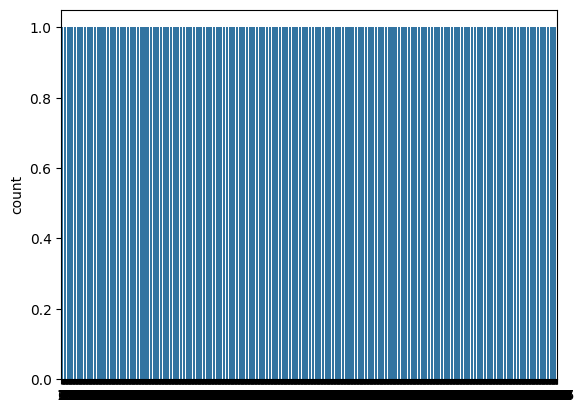

In [19]:
sns.countplot(df["children"])

<Axes: xlabel='count', ylabel='smoker'>

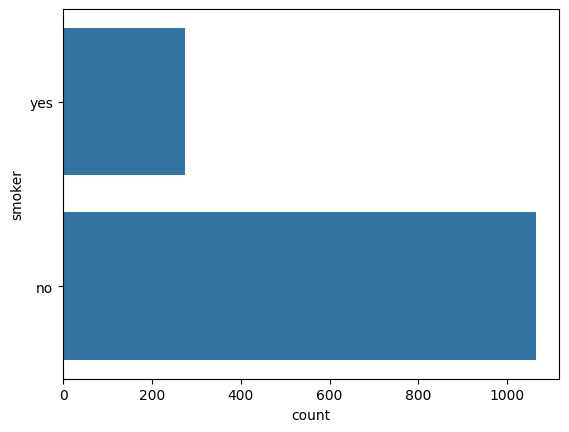

In [20]:
sns.countplot(df["smoker"])

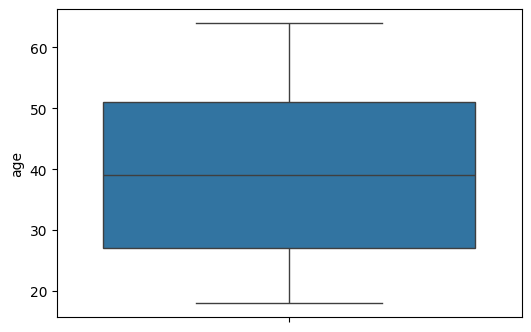

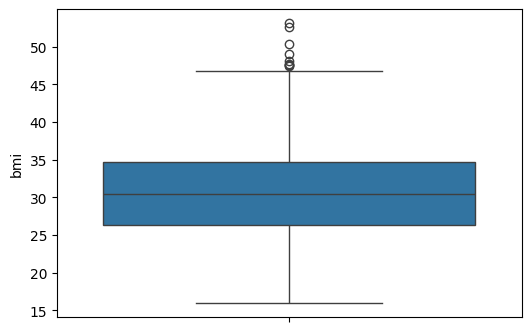

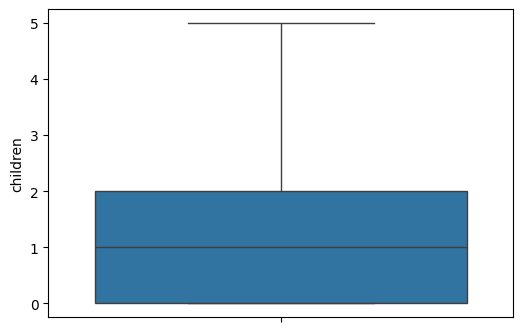

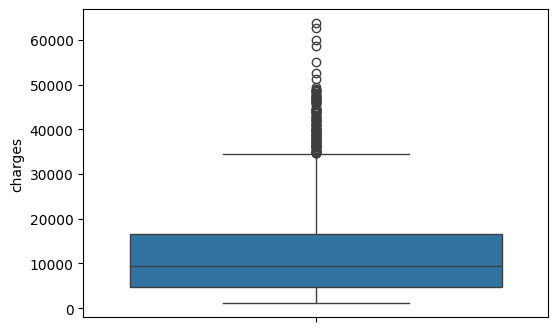

In [21]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    

<Axes: >

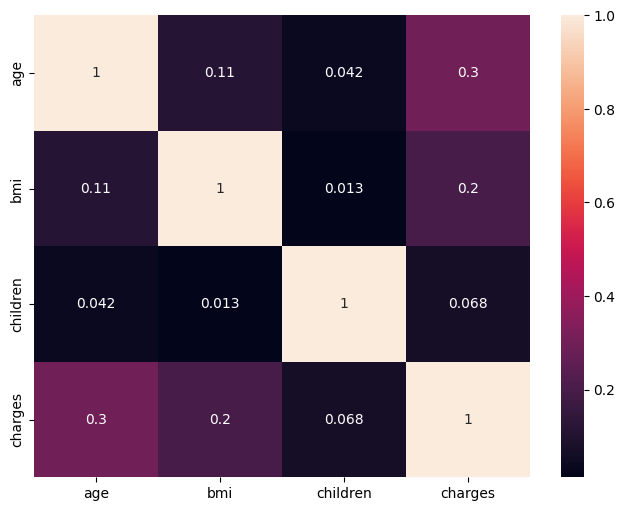

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot= True)

## Cleaning and turning categories into numbers

Drop duplicates, map sex and smoker to 0/1, then expand **region** with dummies so models can use it.

In [23]:
df_cleaned = df.copy()

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned.shape

(1338, 7)

In [26]:
df_cleaned.drop_duplicates(inplace = True)

In [27]:
df_cleaned.shape

(1337, 7)

In [28]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [29]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [30]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [31]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0, "female" : 1})

In [32]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [33]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [34]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0 , "yes":1})

In [35]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [36]:
df_cleaned.rename(columns={
    'sex': 'is_male',
    'smoker': 'is_smoker'
},inplace = True)

In [37]:
df_cleaned

,age,is_male,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [38]:
df_cleaned.head

<bound method NDFrame.head of       age  is_male     bmi  children  is_smoker     region      charges
0      19        1  27.900         0          1  southwest  16884.92400
1      18        0  33.770         1          0  southeast   1725.55230
2      28        0  33.000         3          0  southeast   4449.46200
3      33        0  22.705         0          0  northwest  21984.47061
4      32        0  28.880         0          0  northwest   3866.85520
...   ...      ...     ...       ...        ...        ...          ...
1333   50        0  30.970         3          0  northwest  10600.54830
1334   18        1  31.920         0          0  northeast   2205.98080
1335   18        1  36.850         0          0  southeast   1629.83350
1336   21        1  25.800         0          0  southwest   2007.94500
1337   61        1  29.070         0          1  northwest  29141.36030

[1337 rows x 7 columns]>

In [39]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [40]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [41]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [42]:
df_cleaned = df_cleaned.astype(int)

In [43]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [44]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


## BMI bands and extra dummy columns

Histogram of BMI, then **cut** into underweight / normal / overweight / obesity and one-hot those labels like we did for region.

<Axes: xlabel='bmi', ylabel='Count'>

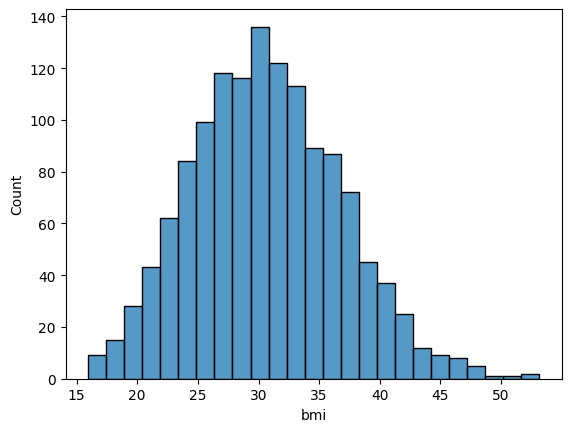

In [45]:
sns.histplot(df['bmi'])

In [46]:
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float('inf')],
    labels = ['underweight', 'normal', 'overweight', 'obesity']
)

In [47]:
df_cleaned

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obesity
2,28,0,33,3,0,4449,0,1,0,obesity
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obesity
1334,18,1,31,0,0,2205,0,0,0,obesity
1335,18,1,36,0,0,1629,0,1,0,obesity
1336,21,1,25,0,0,2007,0,0,1,overweight


In [48]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [49]:
df_cleaned.astype(int)

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [50]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [51]:
df_cleaned.columns

Index(['age', 'is_male', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight',
       'bmi_category_obesity'],
      dtype='object')

## Standardizing age, BMI, and children

Same scale (mean 0, std 1) so those three columns are comparable. For real projects we’d fit the scaler on train only — here we’re keeping the notebook simple.

In [52]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [53]:
df_cleaned.head()

,age,is_male,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False


## How linearly each column tracks with charges

Pearson *r* vs `charges` for the numeric and dummy features we care about. Sorted so the strongest linear relationships float to the top.

In [54]:
from scipy.stats import pearsonr

selected_features = ['age', 'bmi', 'children', 'charges', 'is_male', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obesity']

correlation = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature','Pearson_Correlation'])
correlation_df.sort_values(by='Pearson_Correlation', ascending=False)




,Feature,Pearson_Correlation
3,charges,1.000000
5,is_smoker,0.787234
0,age,0.298309
11,bmi_category_obesity,0.200348
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
4,is_male,-0.058046


In [55]:
catogorical_features = ['is_male', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obesity']

## Chi-square: categories vs charge quartiles

Split `charges` into four buckets with `qcut`, cross-tab each categorical feature with those buckets, and run a chi-square test. Small **p-value** → association worth keeping in mind for feature selection.

In [60]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in catogorical_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat , p_value, _, _ = chi2_contingency(contingency)
    decision = "Reject Null (Keep feature)" if p_value < alpha else "Fail to Reject Null (Drop feature)"
    chi2_results[col] = {
        'chi2_stat': chi2_stat,
        'p_value': p_value,
        'decision': decision
    }
chi2_results_df = pd.DataFrame(chi2_results).T
chi2_results_df = chi2_results_df.sort_values(by='p_value')
chi2_results_df



,chi2_stat,p_value,decision
is_smoker,848.219178,0.0,Reject Null (Keep feature)
region_southeast,15.998167,0.001135,Reject Null (Keep feature)
is_male,10.258784,0.01649,Reject Null (Keep feature)
bmi_category_obesity,8.515711,0.036473,Reject Null (Keep feature)
region_southwest,5.091893,0.165191,Fail to Reject Null (Drop feature)
bmi_category_overweight,4.25149,0.235557,Fail to Reject Null (Drop feature)
bmi_category_normal,3.708088,0.29476,Fail to Reject Null (Drop feature)
region_northwest,1.13424,0.768815,Fail to Reject Null (Drop feature)


## Columns we’re carrying forward

A trimmed `final_df` with the features (and target) we’ll use when we start modeling.

In [62]:
final_df = df_cleaned[['age', 'bmi', 'children', 'is_male', 'is_smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']]
final_df.head()






,age,bmi,children,is_male,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.517949,-0.909234,1,1,16884,0,0,1
1,-1.511647,0.462463,-0.079442,0,0,1725,0,1,0
2,-0.799350,0.462463,1.580143,0,0,4449,0,1,0
3,-0.443201,-1.334960,-0.909234,0,0,21984,1,0,0
4,-0.514431,-0.354547,-0.909234,0,0,3866,1,0,0
